# Probing Pipeline Visualization

End-to-end visualization of the final attentive probe pipeline that evaluates pretrained representations:
1. **Config & data loading** — probe-specific hyperparameters and MassSpecGym dataset
2. **Probe dataset** — batch structure with classification labels (adduct, instrument, precursor bin)
3. **Label distributions** — class balance across the three probe tasks
4. **Feature extraction** — frozen encoder → PMA pooling → projector (or raw encoder tokens)
5. **Probe architecture** — FinalAttentiveProbe with learned task queries + cross-attention
6. **LR schedule** — cosine decay with warmup
7. **Single probe step** — forward pass, losses, logits, and accuracy computation
8. **Attention weights** — what the probe attends to in the feature tokens

In [1]:
import sys, os
os.chdir(os.path.join(os.path.dirname(os.path.abspath('.')), ''))
sys.path.insert(0, os.path.abspath('..'))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import torch
import torch.nn.functional as F

# Project imports
from input_pipeline import TfLightningDataModule, numpy_batch_to_torch
from configs.gems_a_50_mask import get_config
from utils.training import build_model_from_config
from utils.probing import (
    FinalAttentiveProbe, FinalLinearProbe,
    iter_massspec_probe, probe_steps_per_epoch,
    precursor_mz_to_bins, _extract_probe_features, _probe_step,
    PROBE_TASK_NAMES,
)
from utils.schedulers import learning_rate_at_step

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

cfg = get_config()
dm = TfLightningDataModule(cfg, seed=42)

# Probe-specific config
print('=== Probe Configuration ===')
print(f'Feature source: {cfg.final_probe_feature_source}')
print(f'Probe epochs: {cfg.final_probe_num_epochs}')
print(f'Probe LR: {cfg.final_probe_learning_rate}')
print(f'Probe weight decay: {cfg.final_probe_weight_decay}')
print(f'Probe warmup steps: {cfg.final_probe_warmup_steps}')
print(f'Probe hidden dim: {cfg.final_probe_head_hidden_dim}')
print(f'Probe attention heads: {cfg.final_probe_attention_heads}')
print(f'Precursor bins: {cfg.final_probe_num_precursor_bins}')
print(f'Loss weights: {cfg.final_probe_loss_weights}')
print(f'Freeze backbone: {cfg.final_probe_freeze_backbone}')
print()
print('=== Dataset Info ===')
for k in sorted(dm.info):
    if 'massspec' in k or 'vocab' in k:
        print(f'  {k}: {dm.info[k]}')

/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Probe Configuration ===
Feature source: projector
Probe epochs: 5
Probe LR: 0.0001
Probe weight decay: 0.0001
Probe warmup steps: 50
Probe hidden dim: 512
Probe attention heads: 8
Precursor bins: 1000
Loss weights: [1.0, 1.0, 1.0]
Freeze backbone: True

=== Dataset Info ===
  massspec_adduct_vocab: {'unknown': 0, '[M+H]+': 1, '[M+Na]+': 2}
  massspec_adduct_vocab_size: 3
  massspec_instrument_type_vocab: {'unknown': 0, 'Orbitrap': 1, 'QTOF': 2}
  massspec_instrument_type_vocab_size: 3
  massspec_metadata_version: 2
  massspec_test_size: 17556
  massspec_train_size: 194119
  massspec_val_size: 19429


## 1. Probe Dataset: Batch Structure

The probe uses MassSpecGym data (separate from GeMS pretraining data). Each batch has `peak_mz`, `peak_intensity`, `peak_valid_mask`, `precursor_mz`, plus classification labels: `adduct_id` and `instrument_type_id`.

In [2]:
# Get a batch from the probe train dataset
probe_seed = 42
probe_batches = list(iter_massspec_probe(
    dm, 'massspec_train',
    seed=probe_seed,
    peak_ordering=cfg.peak_ordering,
    drop_remainder=True,
))
batch = probe_batches[0]

print(f'Number of train batches: {len(probe_batches)}')
print(f'Steps per epoch (train): {probe_steps_per_epoch(dm, split="massspec_train", drop_remainder=False)}')
print(f'Steps per epoch (test): {probe_steps_per_epoch(dm, split="massspec_test", drop_remainder=False)}')
print()
print('Batch keys and shapes:')
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(f'  {k}: shape={list(v.shape)}, dtype={v.dtype}')
    else:
        print(f'  {k}: {type(v).__name__}')

Number of train batches: 379
Steps per epoch (train): 380
Steps per epoch (test): 35

Batch keys and shapes:
  peak_mz: shape=[512, 60], dtype=torch.float32
  peak_intensity: shape=[512, 60], dtype=torch.float32
  peak_valid_mask: shape=[512, 60], dtype=torch.bool
  precursor_mz: shape=[512], dtype=torch.float32
  rt: shape=[512], dtype=torch.float32
  mz: shape=[512, 60], dtype=torch.float32
  intensity: shape=[512, 60], dtype=torch.float32
  fingerprint: shape=[512, 1024], dtype=torch.int32
  adduct_id: shape=[512], dtype=torch.int32
  instrument_type_id: shape=[512], dtype=torch.int32
  collision_energy: shape=[512], dtype=torch.float32
  collision_energy_present: shape=[512], dtype=torch.int32


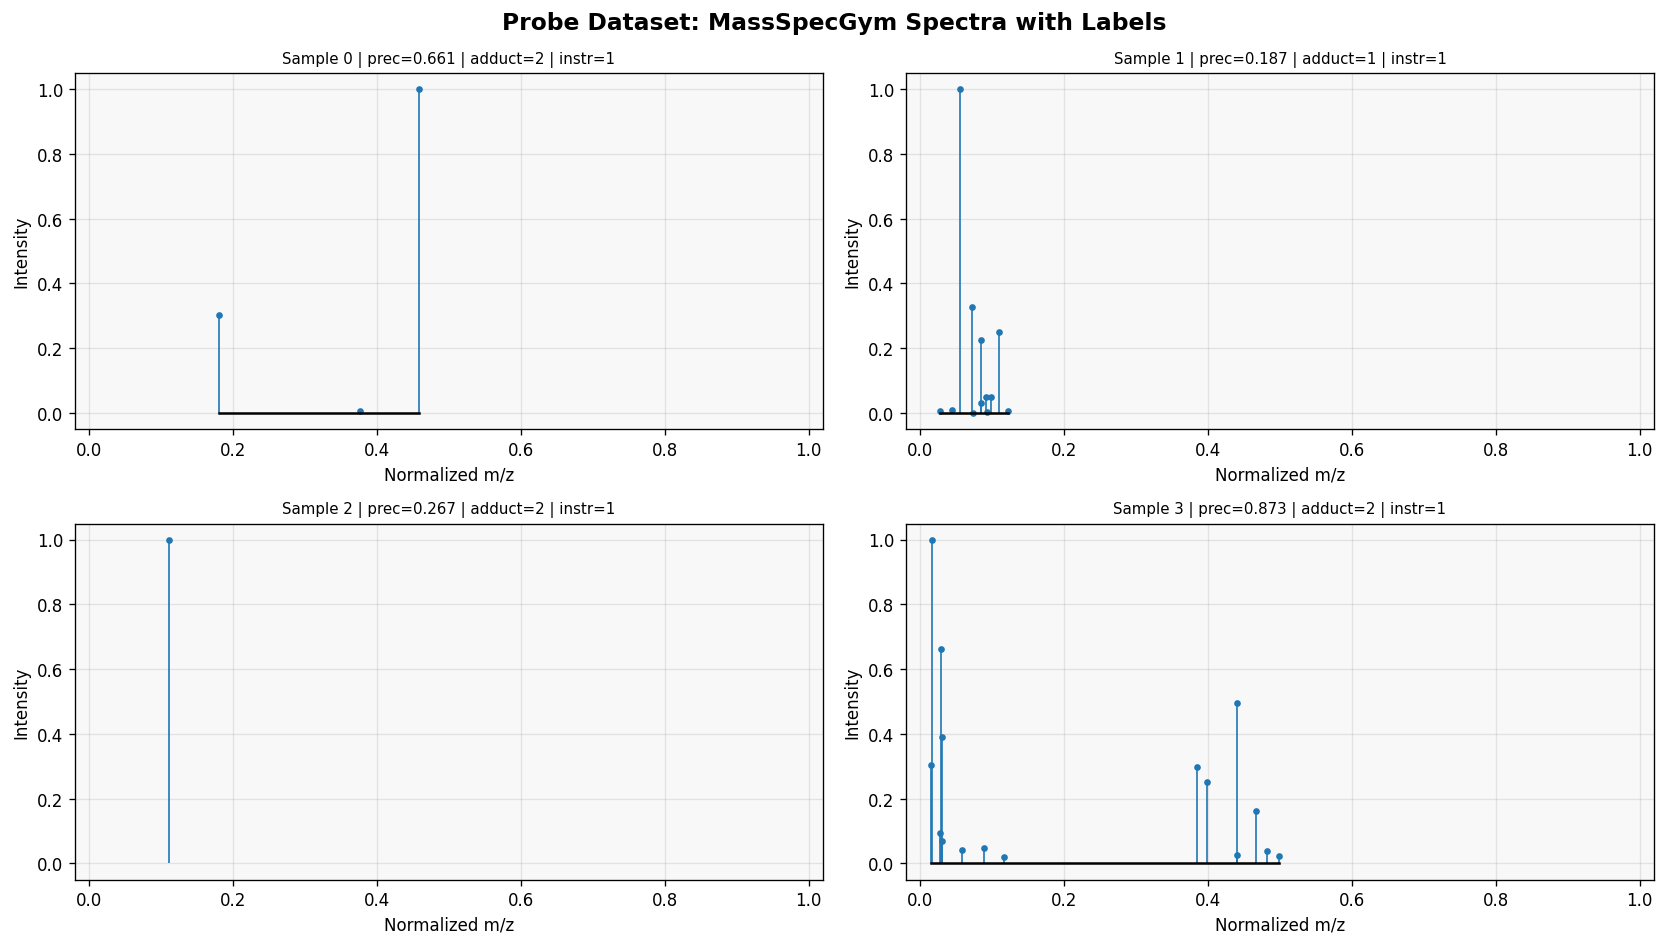

In [3]:
# Visualize 4 probe spectra with their labels
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Probe Dataset: MassSpecGym Spectra with Labels', fontsize=14, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    mz = batch['peak_mz'][idx].numpy()
    intensity = batch['peak_intensity'][idx].numpy()
    valid = batch['peak_valid_mask'][idx].numpy().astype(bool)
    prec = batch['precursor_mz'][idx].item()
    adduct = batch['adduct_id'][idx].item()
    instrument = batch['instrument_type_id'][idx].item()
    
    v_idx = np.where(valid)[0]
    if len(v_idx) > 0:
        markerline, stemlines, baseline = ax.stem(
            mz[v_idx], intensity[v_idx],
            linefmt='C0-', markerfmt='C0o', basefmt='k-',
        )
        stemlines.set_linewidth(1.0)
        markerline.set_markersize(3)
    
    ax.set_title(
        f'Sample {idx} | prec={prec:.3f} | adduct={adduct} | instr={instrument}',
        fontsize=9,
    )
    ax.set_xlabel('Normalized m/z')
    ax.set_ylabel('Intensity')
    ax.set_xlim(-0.02, 1.02)

plt.tight_layout()
plt.savefig('notebooks/fig_probe_spectra.png', bbox_inches='tight')
plt.show()

## 2. Label Distributions

Three probe tasks:
- **Adduct classification** — chemical adduct type (e.g. [M+H]+, [M+Na]+)
- **Precursor bin prediction** — precursor m/z quantized into 1000 bins
- **Instrument type identification** — mass spectrometer type

Total train samples: 194,048
Adduct classes: 3
Instrument classes: 3
Precursor bins: 1000


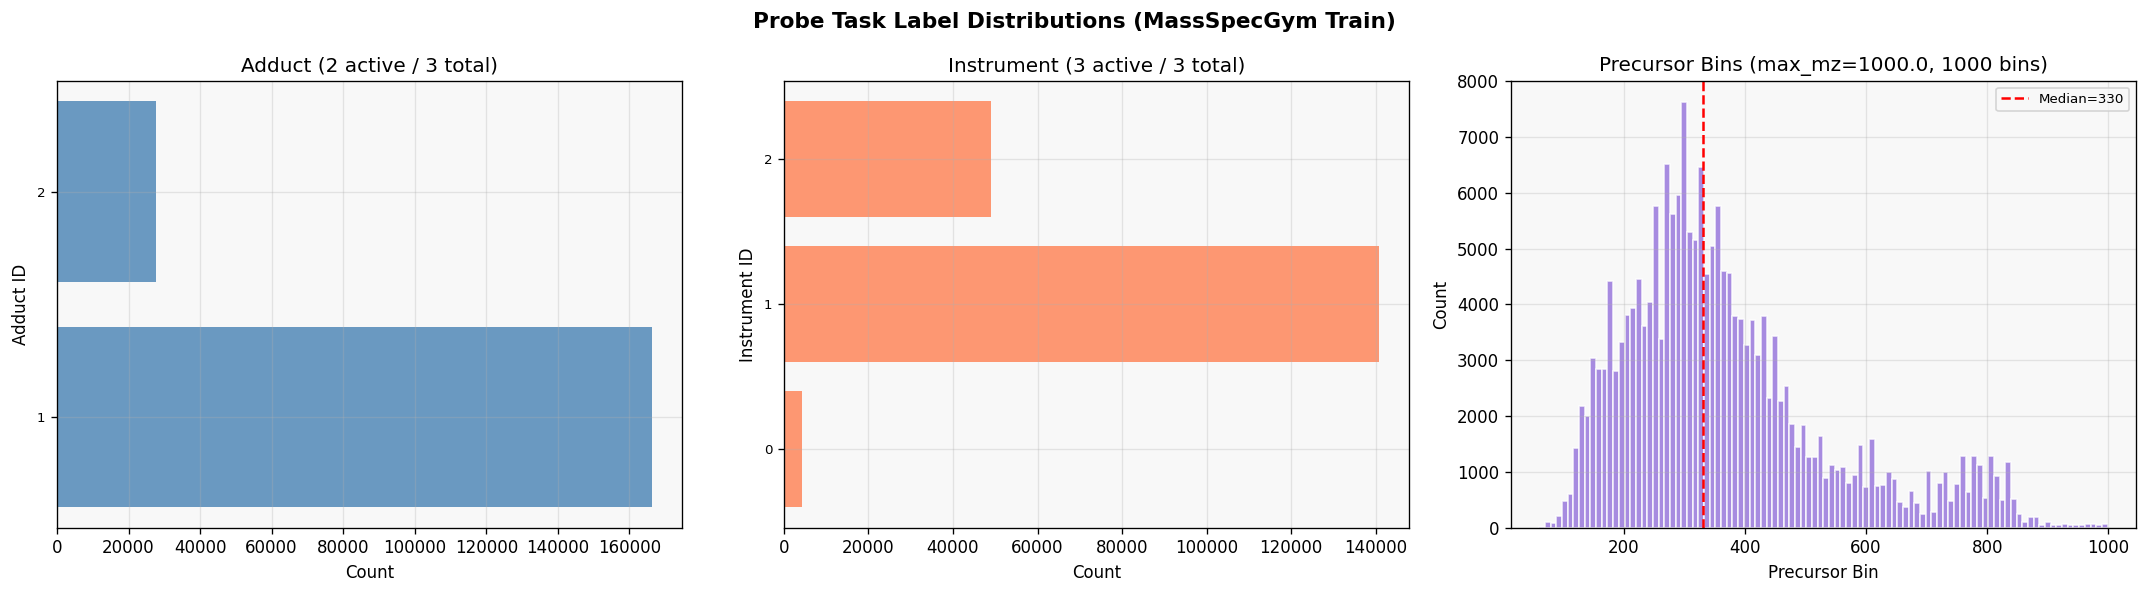

In [4]:
# Collect labels from all train batches
all_adducts = torch.cat([b['adduct_id'] for b in probe_batches]).numpy()
all_instruments = torch.cat([b['instrument_type_id'] for b in probe_batches]).numpy()
all_precursor_mz = torch.cat([b['precursor_mz'] for b in probe_batches])
all_precursor_bins = precursor_mz_to_bins(
    all_precursor_mz,
    num_bins=int(cfg.final_probe_num_precursor_bins),
    max_mz=float(cfg.max_precursor_mz),
).numpy()

num_adduct_classes = int(dm.info['massspec_adduct_vocab_size'])
num_instrument_classes = int(dm.info['massspec_instrument_type_vocab_size'])
num_precursor_bins = int(cfg.final_probe_num_precursor_bins)

print(f'Total train samples: {len(all_adducts):,}')
print(f'Adduct classes: {num_adduct_classes}')
print(f'Instrument classes: {num_instrument_classes}')
print(f'Precursor bins: {num_precursor_bins}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Probe Task Label Distributions (MassSpecGym Train)', fontsize=13, fontweight='bold')

# Adduct distribution
ax = axes[0]
adduct_counts = np.bincount(all_adducts, minlength=num_adduct_classes)
nonzero_adducts = np.where(adduct_counts > 0)[0]
ax.barh(range(len(nonzero_adducts)), adduct_counts[nonzero_adducts], color='steelblue', alpha=0.8)
ax.set_yticks(range(len(nonzero_adducts)))
ax.set_yticklabels([str(a) for a in nonzero_adducts], fontsize=8)
ax.set_xlabel('Count')
ax.set_ylabel('Adduct ID')
ax.set_title(f'Adduct ({len(nonzero_adducts)} active / {num_adduct_classes} total)')

# Instrument distribution
ax = axes[1]
instr_counts = np.bincount(all_instruments, minlength=num_instrument_classes)
nonzero_instr = np.where(instr_counts > 0)[0]
ax.barh(range(len(nonzero_instr)), instr_counts[nonzero_instr], color='coral', alpha=0.8)
ax.set_yticks(range(len(nonzero_instr)))
ax.set_yticklabels([str(i) for i in nonzero_instr], fontsize=8)
ax.set_xlabel('Count')
ax.set_ylabel('Instrument ID')
ax.set_title(f'Instrument ({len(nonzero_instr)} active / {num_instrument_classes} total)')

# Precursor bin distribution
ax = axes[2]
ax.hist(all_precursor_bins, bins=100, color='mediumpurple', edgecolor='white', alpha=0.8)
ax.set_xlabel('Precursor Bin')
ax.set_ylabel('Count')
ax.set_title(f'Precursor Bins (max_mz={cfg.max_precursor_mz}, {num_precursor_bins} bins)')
ax.axvline(np.median(all_precursor_bins), color='red', ls='--', label=f'Median={np.median(all_precursor_bins):.0f}')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/fig_probe_labels.png', bbox_inches='tight')
plt.show()

## 3. Feature Extraction Pipeline

The probe extracts features from the frozen pretrained backbone:

```
peak_mz, peak_intensity, valid_mask
    │
    └── Encoder (FourierFeatures → MLP → TransformerBlocks → RMSNorm)
         │  output: [B, N, model_dim]
         │
         ├── feature_source="encoder" → raw token embeddings [B, N, model_dim]
         │
         └── feature_source="projector" → PMA pool → Projector → [B, 1, proj_dim]
```

In [5]:
# Build a randomly-initialized model to demonstrate feature extraction shapes
device = torch.device('cpu')
cfg.num_peaks = int(dm.info['num_peaks'])
model = build_model_from_config(cfg)
model.to(device)
model.eval()

print('=== Model Architecture ===')
total_params = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.encoder.parameters())
projector_params = sum(p.numel() for p in model.projector.parameters()) if model.projector is not None else 0
print(f'Total params: {total_params:,}')
print(f'Encoder params: {encoder_params:,}')
print(f'Projector params: {projector_params:,}')
print(f'Pooling type: {model.pooling_type}')
print(f'PMA seeds: {model.pma_num_seeds}')
print(f'Model dim: {model.model_dim}')
print(f'SIGReg dim (projector output): {model.sigreg_dim}')
print()

# Run feature extraction on a single batch
small_batch = {k: v[:8].to(device) for k, v in batch.items() if isinstance(v, torch.Tensor)}

with torch.no_grad():
    # Encoder features
    enc_features, enc_mask = _extract_probe_features(
        model, small_batch, feature_source='encoder',
    )
    # Projector features
    proj_features, proj_mask = _extract_probe_features(
        model, small_batch, feature_source='projector',
    )

print('=== Feature Shapes ===')
print(f'Encoder features: {list(enc_features.shape)} (tokens x model_dim={cfg.model_dim})')
print(f'Encoder mask: {list(enc_mask.shape)}')
print(f'Projector features: {list(proj_features.shape)} (1 pooled token x proj_dim={cfg.sigreg_proj_output_dim})')
print(f'Projector mask: {list(proj_mask.shape)}')

=== Model Architecture ===
Total params: 12,525,056
Encoder params: 7,264,128
Projector params: 4,989,056
Pooling type: pma
PMA seeds: 32
Model dim: 256
SIGReg dim (projector output): 128



/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/torch/nn/attention/flex_attention.py:1624: UserWarning: flex_attention called without torch.compile() - this will use an unfused implementation that materializes the full scores matrix instead of generating a fused kernel.

SOLUTION: Use torch.compile(flex_attention)(...)

If you want to debug your score_mod/mask_mod, you can set:
torch.nn.attention.flex_attention._FLEX_ATTENTION_DISABLE_COMPILE_DEBUG = True

This will allow you to use print statements or breakpoints. Note: This doesn't work with the backwards pass and may produce incorrect results.
  _warn_once(


=== Feature Shapes ===
Encoder features: [8, 60, 256] (tokens x model_dim=256)
Encoder mask: [8, 60]
Projector features: [8, 1, 128] (1 pooled token x proj_dim=128)
Projector mask: [8, 1]


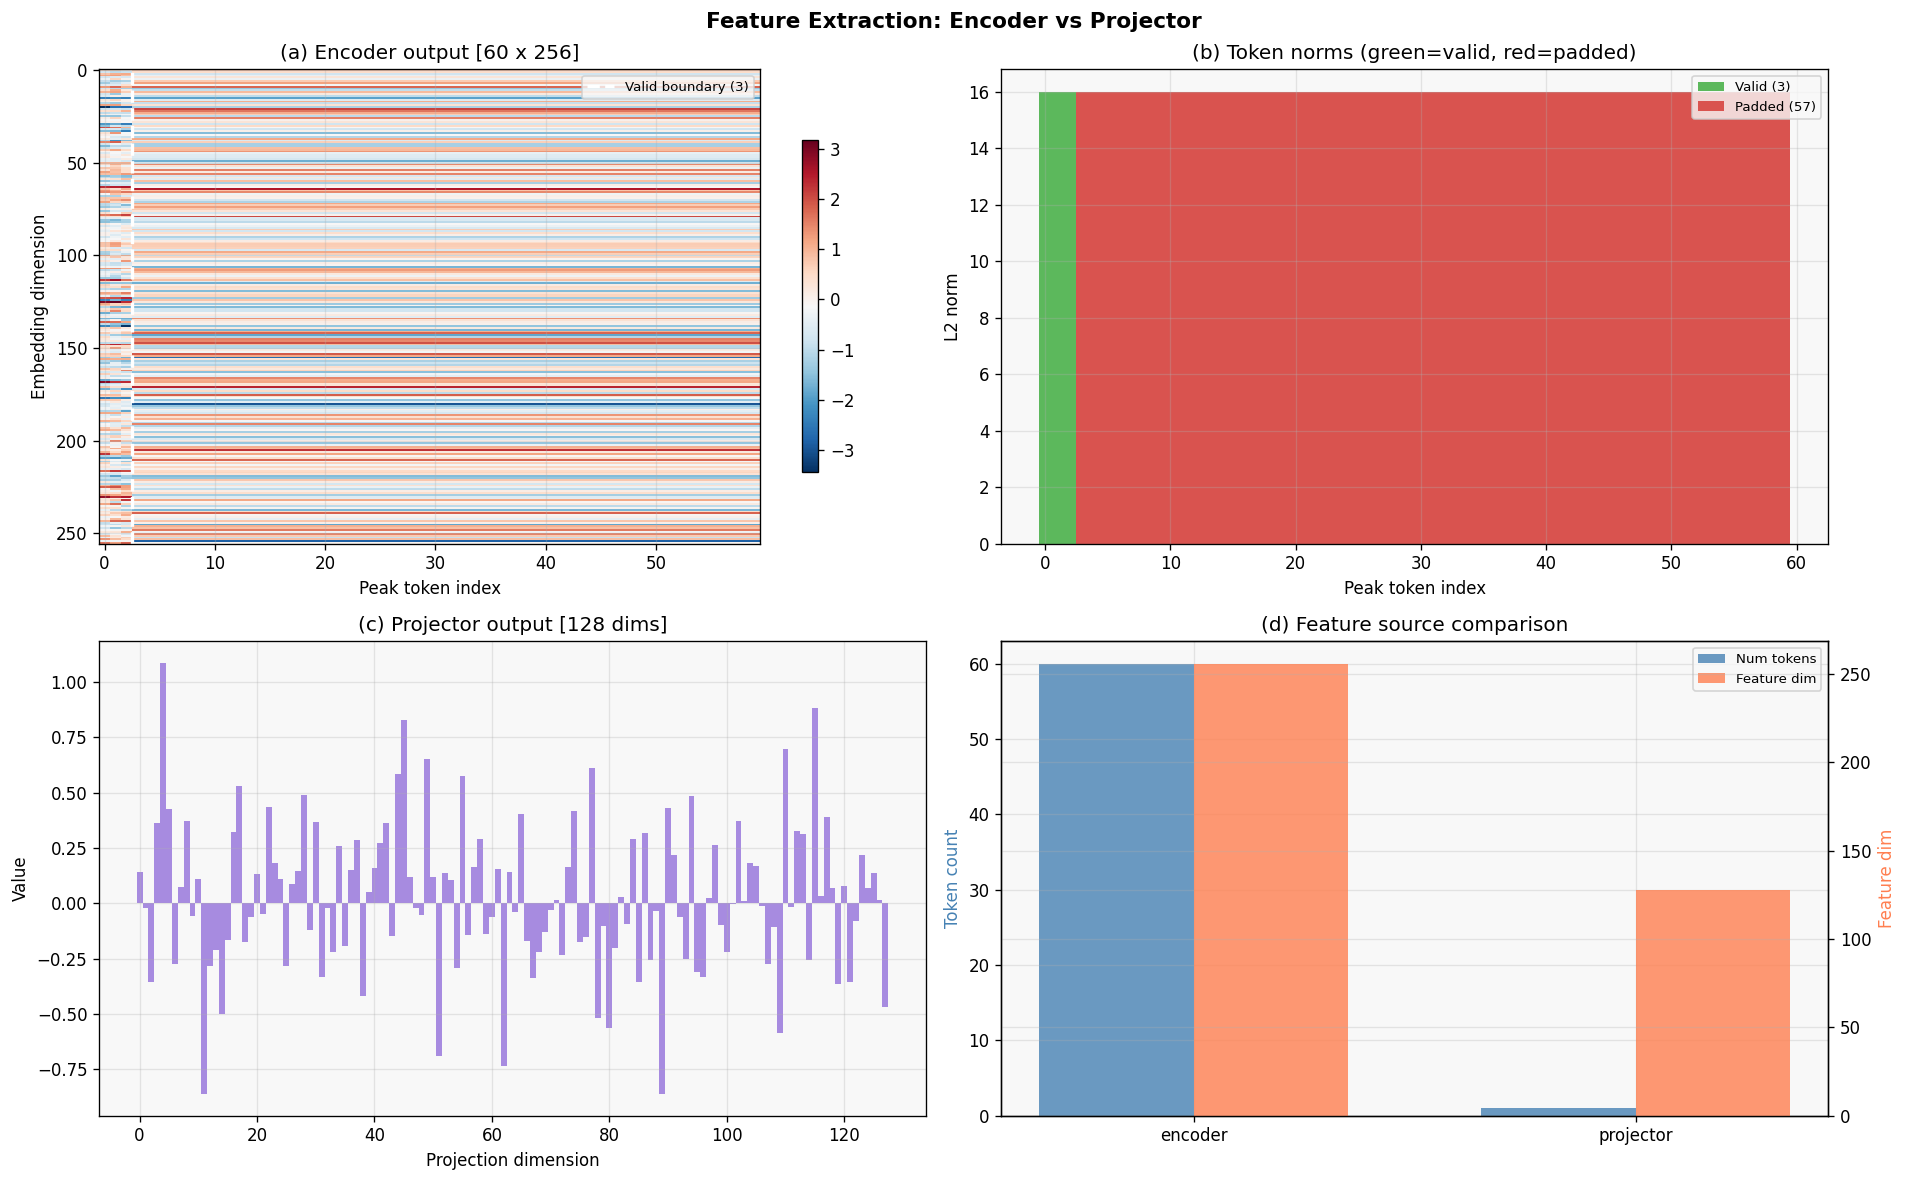

In [6]:
# Visualize encoder feature tokens for a single sample
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Feature Extraction: Encoder vs Projector', fontsize=13, fontweight='bold')

sample_idx = 0
enc_np = enc_features[sample_idx].numpy()  # [N, model_dim]
valid_np = enc_mask[sample_idx].numpy().astype(bool)
proj_np = proj_features[sample_idx].numpy()  # [1, proj_dim]

# (a) Encoder token heatmap
ax = axes[0, 0]
im = ax.imshow(enc_np.T, aspect='auto', cmap='RdBu_r', interpolation='nearest')
n_valid = valid_np.sum()
ax.axvline(n_valid - 0.5, color='white', ls='--', lw=2, label=f'Valid boundary ({n_valid})')
ax.set_xlabel('Peak token index')
ax.set_ylabel('Embedding dimension')
ax.set_title(f'(a) Encoder output [{cfg.num_peaks} x {cfg.model_dim}]')
ax.legend(fontsize=8, loc='upper right')
plt.colorbar(im, ax=ax, shrink=0.7)

# (b) Encoder token norms (valid vs padded)
ax = axes[0, 1]
token_norms = np.linalg.norm(enc_np, axis=1)  # [N]
colors = ['#5cb85c' if v else '#d9534f' for v in valid_np]
ax.bar(range(len(token_norms)), token_norms, color=colors, width=1.0)
ax.set_xlabel('Peak token index')
ax.set_ylabel('L2 norm')
ax.set_title('(b) Token norms (green=valid, red=padded)')
ax.legend(handles=[
    Patch(facecolor='#5cb85c', label=f'Valid ({n_valid})'),
    Patch(facecolor='#d9534f', label=f'Padded ({(~valid_np).sum()})'),
], fontsize=8)

# (c) Projector output (single pooled vector)
ax = axes[1, 0]
ax.bar(range(proj_np.shape[1]), proj_np[0], color='mediumpurple', width=1.0, alpha=0.8)
ax.set_xlabel('Projection dimension')
ax.set_ylabel('Value')
ax.set_title(f'(c) Projector output [{cfg.sigreg_proj_output_dim} dims]')

# (d) Feature source comparison: token count and dimensionality
ax = axes[1, 1]
sources = ['encoder', 'projector']
token_counts = [enc_features.shape[1], proj_features.shape[1]]
dims = [enc_features.shape[2], proj_features.shape[2]]
x = np.arange(len(sources))
w = 0.35
ax.bar(x - w/2, token_counts, w, label='Num tokens', color='steelblue', alpha=0.8)
ax2 = ax.twinx()
ax2.bar(x + w/2, dims, w, label='Feature dim', color='coral', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(sources)
ax.set_ylabel('Token count', color='steelblue')
ax2.set_ylabel('Feature dim', color='coral')
ax.set_title('(d) Feature source comparison')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/fig_probe_features.png', bbox_inches='tight')
plt.show()

## 4. Probe Architecture

**FinalAttentiveProbe**: Uses learned task queries (one per task) that cross-attend to feature tokens, then routes through a shared trunk (Linear → RMSNorm → SiLU) before per-task classification heads.

```
feature_tokens [B, N, D]    task_queries [3, D]
        │                         │
        └────── MultiheadAttention(Q=queries, K=V=tokens) ──────┘
                       │
                 attended [B, 3, D]
                       │
                 trunk (Linear → RMSNorm → SiLU)
                       │
                 states [B, 3, hidden_dim]
                       │
             ┌─────────┼─────────┐
         states[:,0,:]  states[:,1,:]  states[:,2,:]
             │               │               │
        head_adduct   head_precursor  head_instrument
             │               │               │
        logits_adduct logits_precursor logits_instrument
```

In [7]:
# Build the probe (same as in run_attentive_probe)
use_projector = cfg.final_probe_feature_source == 'projector' and bool(cfg.get('sigreg_use_projector', True))
input_dim = int(cfg.sigreg_proj_output_dim) if use_projector else int(cfg.model_dim)

probe = FinalAttentiveProbe(
    input_dim=input_dim,
    hidden_dim=int(cfg.final_probe_head_hidden_dim),
    num_attention_heads=int(cfg.final_probe_attention_heads),
    head_dims={
        'adduct': num_adduct_classes,
        'precursor_bin': num_precursor_bins,
        'instrument': num_instrument_classes,
    },
).to(device)

probe_params = sum(p.numel() for p in probe.parameters())
print(f'=== Probe Architecture (feature_source={cfg.final_probe_feature_source}) ===')
print(f'Input dim: {input_dim}')
print(f'Hidden dim: {cfg.final_probe_head_hidden_dim}')
print(f'Attention heads: {cfg.final_probe_attention_heads}')
print(f'Num task queries: {probe.task_queries.shape[0]} (one per task)')
print(f'Total probe params: {probe_params:,}')
print()
print('Per-component param counts:')
attn_params = sum(p.numel() for p in probe.attention.parameters())
trunk_params = sum(p.numel() for p in probe.trunk.parameters())
head_params = sum(p.numel() for p in probe.heads.parameters())
query_params = probe.task_queries.numel()
print(f'  Task queries: {query_params:,}')
print(f'  Attention: {attn_params:,}')
print(f'  Trunk: {trunk_params:,}')
print(f'  Heads: {head_params:,}')
for name, head in probe.heads.items():
    hp = sum(p.numel() for p in head.parameters())
    print(f'    {name}: {hp:,} (output dim={head.out_features})')
print()
print(probe)

=== Probe Architecture (feature_source=projector) ===
Input dim: 128
Hidden dim: 512
Attention heads: 8
Num task queries: 3 (one per task)
Total probe params: 649,070

Per-component param counts:
  Task queries: 384
  Attention: 66,048
  Trunk: 66,560
  Heads: 516,078
    adduct: 1,539 (output dim=3)
    precursor_bin: 513,000 (output dim=1000)
    instrument: 1,539 (output dim=3)

FinalAttentiveProbe(
  (heads): ModuleDict(
    (adduct): Linear(in_features=512, out_features=3, bias=True)
    (precursor_bin): Linear(in_features=512, out_features=1000, bias=True)
    (instrument): Linear(in_features=512, out_features=3, bias=True)
  )
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (trunk): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): RMSNorm((512,), eps=None, elementwise_affine=True)
    (2): SiLU()
  )
)


=== Linear Probe (for comparison) ===
Total params: 129,774
Attentive probe params: 649,070
Ratio (attentive/linear): 5.0x



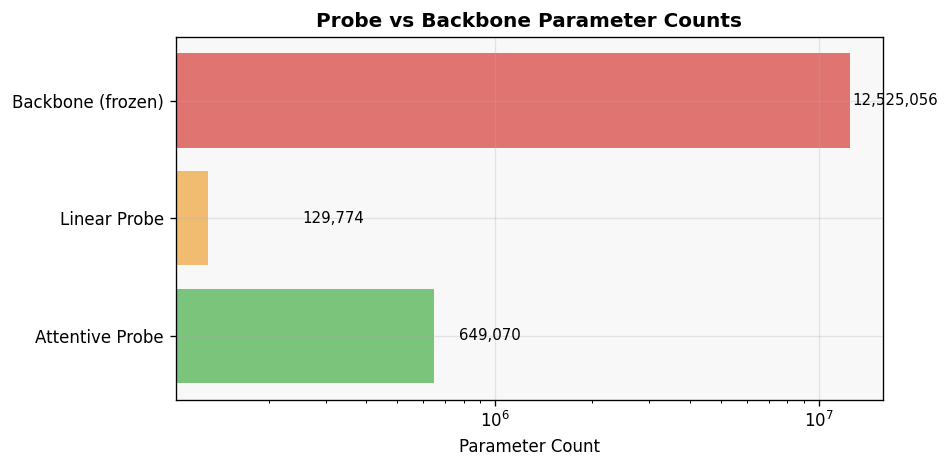

In [8]:
# Also show the linear probe for comparison
linear_probe = FinalLinearProbe(
    input_dim=input_dim,
    head_dims={
        'adduct': num_adduct_classes,
        'precursor_bin': num_precursor_bins,
        'instrument': num_instrument_classes,
    },
).to(device)

linear_params = sum(p.numel() for p in linear_probe.parameters())
print(f'=== Linear Probe (for comparison) ===')
print(f'Total params: {linear_params:,}')
print(f'Attentive probe params: {probe_params:,}')
print(f'Ratio (attentive/linear): {probe_params/linear_params:.1f}x')
print()

# Bar chart comparing probe sizes
fig, ax = plt.subplots(figsize=(8, 4))
probes = ['Attentive Probe', 'Linear Probe', 'Backbone (frozen)']
params = [probe_params, linear_params, total_params]
colors = ['#5cb85c', '#f0ad4e', '#d9534f']
bars = ax.barh(probes, params, color=colors, alpha=0.8)
for bar, p in zip(bars, params):
    ax.text(bar.get_width() + max(params)*0.01, bar.get_y() + bar.get_height()/2,
            f'{p:,}', va='center', fontsize=9)
ax.set_xlabel('Parameter Count')
ax.set_title('Probe vs Backbone Parameter Counts', fontweight='bold')
ax.set_xscale('log')
plt.tight_layout()
plt.savefig('notebooks/fig_probe_params.png', bbox_inches='tight')
plt.show()

## 5. Learning Rate Schedule

The probe uses a cosine decay schedule with linear warmup.

Steps per epoch: 380
Total steps: 1900
Warmup steps: 50
Base LR: 0.0001


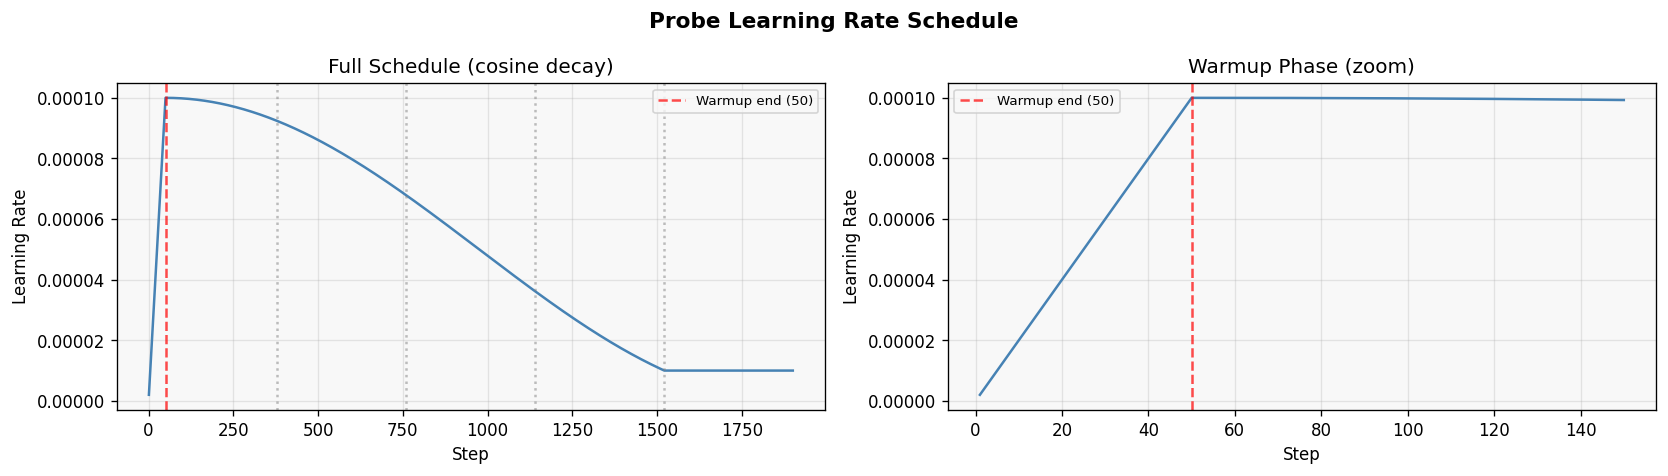

In [9]:
probe_lr = float(cfg.final_probe_learning_rate)
probe_warmup = int(cfg.final_probe_warmup_steps)
steps_per_ep = probe_steps_per_epoch(dm, split='massspec_train', drop_remainder=False)
total_probe_steps = int(cfg.final_probe_num_epochs) * steps_per_ep

print(f'Steps per epoch: {steps_per_ep}')
print(f'Total steps: {total_probe_steps}')
print(f'Warmup steps: {probe_warmup}')
print(f'Base LR: {probe_lr}')

steps = np.arange(1, total_probe_steps + 1)
lrs = [learning_rate_at_step(
    int(s), base_lr=probe_lr, total_steps=total_probe_steps,
    warmup_steps=probe_warmup, schedule_type='cosine', min_learning_rate=None,
) for s in steps]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Probe Learning Rate Schedule', fontsize=13, fontweight='bold')

# Full schedule
ax = axes[0]
ax.plot(steps, lrs, color='steelblue', lw=1.5)
for ep in range(1, int(cfg.final_probe_num_epochs)):
    ax.axvline(ep * steps_per_ep, color='gray', ls=':', alpha=0.5)
ax.axvline(probe_warmup, color='red', ls='--', alpha=0.7, label=f'Warmup end ({probe_warmup})')
ax.set_xlabel('Step')
ax.set_ylabel('Learning Rate')
ax.set_title('Full Schedule (cosine decay)')
ax.legend(fontsize=8)

# Warmup zoom
ax = axes[1]
zoom_end = min(probe_warmup * 3, total_probe_steps)
ax.plot(steps[:zoom_end], lrs[:zoom_end], color='steelblue', lw=1.5)
ax.axvline(probe_warmup, color='red', ls='--', alpha=0.7, label=f'Warmup end ({probe_warmup})')
ax.set_xlabel('Step')
ax.set_ylabel('Learning Rate')
ax.set_title('Warmup Phase (zoom)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/fig_probe_lr.png', bbox_inches='tight')
plt.show()

## 6. Single Probe Step: Forward Pass

Walk through one complete probe step: feature extraction → probe forward → loss + accuracy.

In [10]:
# Run a single probe step
probe.train()
loss_weights = dict(zip(PROBE_TASK_NAMES, cfg.final_probe_loss_weights))

result = _probe_step(
    probe, model, small_batch,
    feature_source=cfg.final_probe_feature_source,
    num_precursor_bins=int(cfg.final_probe_num_precursor_bins),
    precursor_max_mz=float(cfg.max_precursor_mz),
    loss_weights=loss_weights,
)

print('=== Probe Step Output ===')
print(f'Batch size: {result["batch_size"]}')
print(f'Total loss: {result["loss_total"].item():.4f}')
print()
print('Per-task losses:')
for name in PROBE_TASK_NAMES:
    loss = result['losses'][name].item()
    logits = result['logits'][name]
    targets = result['targets'][name]
    preds = logits.argmax(dim=1)
    acc = (preds == targets).float().mean().item()
    print(f'  {name}: loss={loss:.4f}, acc={acc:.4f}, '
          f'logits_shape={list(logits.shape)}, targets_range=[{targets.min()}, {targets.max()}]')

=== Probe Step Output ===
Batch size: 8
Total loss: 9.6481

Per-task losses:
  adduct: loss=0.9166, acc=0.6250, logits_shape=[8, 3], targets_range=[1, 2]
  precursor_bin: loss=7.0905, acc=0.0000, logits_shape=[8, 1000], targets_range=[187, 873]
  instrument: loss=1.6410, acc=0.1250, logits_shape=[8, 3], targets_range=[1, 2]


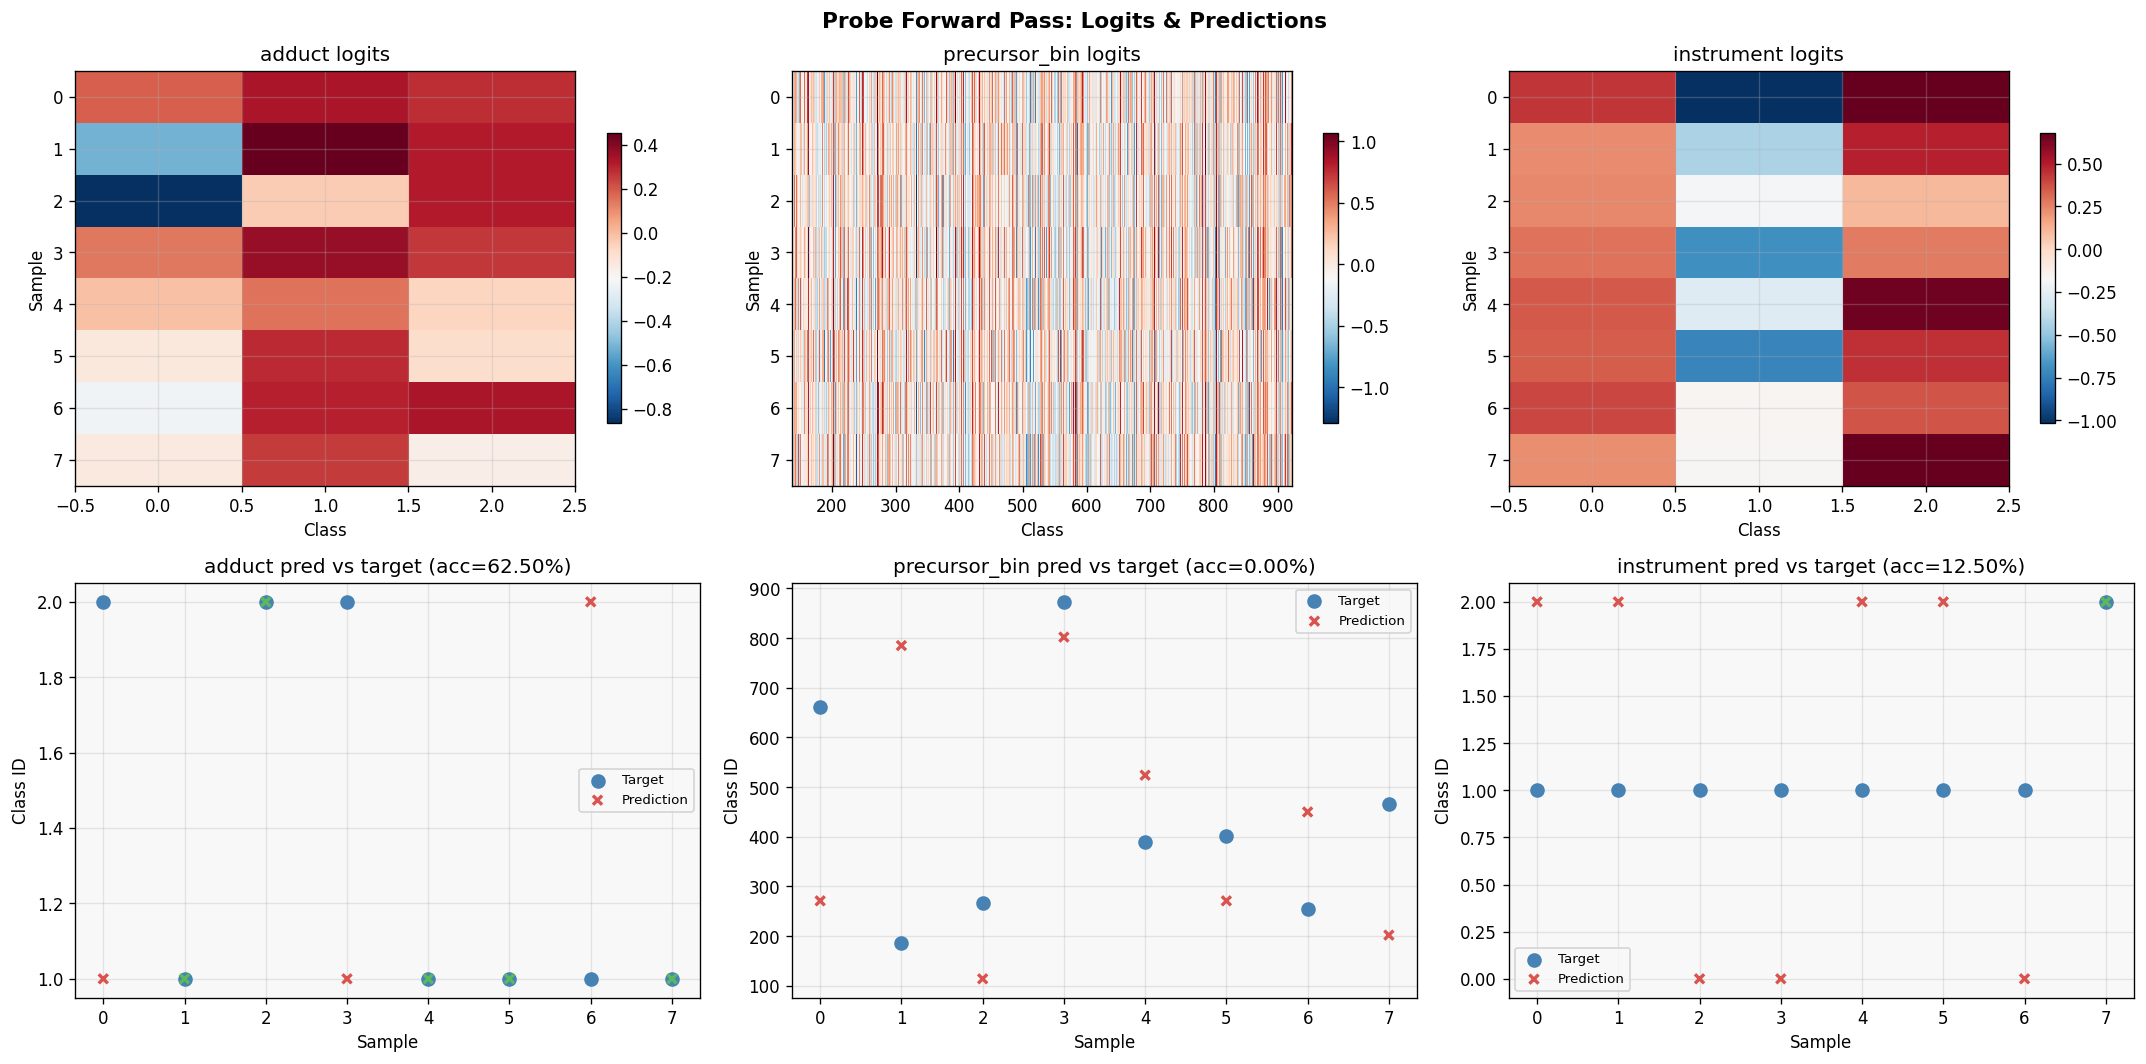

In [11]:
# Visualize logits and targets for each task
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('Probe Forward Pass: Logits & Predictions', fontsize=13, fontweight='bold')

for col, name in enumerate(PROBE_TASK_NAMES):
    logits = result['logits'][name].detach().numpy()  # [B, C]
    targets = result['targets'][name].detach().numpy()  # [B]
    probs = torch.softmax(result['logits'][name].detach(), dim=1).numpy()
    preds = logits.argmax(axis=1)
    
    # Top row: logit heatmap
    ax = axes[0, col]
    # For precursor bins, show only a relevant range
    if name == 'precursor_bin':
        min_bin = max(0, targets.min() - 50)
        max_bin = min(logits.shape[1], targets.max() + 50)
        im = ax.imshow(logits[:, min_bin:max_bin], aspect='auto', cmap='RdBu_r',
                       interpolation='nearest',
                       extent=[min_bin, max_bin, logits.shape[0]-0.5, -0.5])
    else:
        im = ax.imshow(logits, aspect='auto', cmap='RdBu_r', interpolation='nearest')
    ax.set_title(f'{name} logits')
    ax.set_ylabel('Sample')
    ax.set_xlabel('Class')
    plt.colorbar(im, ax=ax, shrink=0.7)
    
    # Bottom row: prediction vs target
    ax = axes[1, col]
    x = np.arange(len(targets))
    correct_mask = preds == targets
    colors = ['#5cb85c' if c else '#d9534f' for c in correct_mask]
    ax.scatter(x, targets, c='steelblue', s=60, marker='o', label='Target', zorder=5)
    ax.scatter(x, preds, c=colors, s=30, marker='x', linewidths=2, label='Prediction', zorder=6)
    acc = correct_mask.mean()
    ax.set_title(f'{name} pred vs target (acc={acc:.2%})')
    ax.set_xlabel('Sample')
    ax.set_ylabel('Class ID')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/fig_probe_step.png', bbox_inches='tight')
plt.show()

## 7. Attention Weights Visualization

What do the probe's learned task queries attend to in the feature tokens?

In [12]:
# Get attention weights from the probe
probe.eval()

with torch.no_grad():
    # Extract features
    feature_tokens, feature_mask = _extract_probe_features(
        model, small_batch, feature_source=cfg.final_probe_feature_source,
    )
    
    # Run attention with weights
    query = probe.task_queries.unsqueeze(0).expand(feature_tokens.shape[0], -1, -1)
    _, attn_weights = probe.attention(
        query=query,
        key=feature_tokens,
        value=feature_tokens,
        key_padding_mask=~feature_mask,
        need_weights=True,
        average_attn_weights=True,  # average over heads
    )

attn_np = attn_weights.numpy()  # [B, num_tasks, num_tokens]
print(f'Attention weights shape: {list(attn_np.shape)}')
print(f'  (batch={attn_np.shape[0]}, tasks={attn_np.shape[1]}, tokens={attn_np.shape[2]})')

# For encoder source, tokens = peaks; for projector source, tokens = 1 pooled vector
num_tokens = attn_np.shape[2]
if num_tokens > 1:
    fig, axes = plt.subplots(len(PROBE_TASK_NAMES), 1, figsize=(14, 3 * len(PROBE_TASK_NAMES)))
    fig.suptitle('Probe Attention Weights per Task Query (averaged across batch)', 
                 fontsize=13, fontweight='bold')
    
    for task_idx, (name, ax) in enumerate(zip(PROBE_TASK_NAMES, axes)):
        # Average attention across batch
        avg_attn = attn_np[:, task_idx, :].mean(axis=0)  # [num_tokens]
        std_attn = attn_np[:, task_idx, :].std(axis=0)
        
        valid_avg = small_batch['peak_valid_mask'][:8].float().mean(dim=0).numpy()
        colors_v = ['#5cb85c' if v > 0.5 else '#d9534f' for v in valid_avg]
        
        ax.bar(range(num_tokens), avg_attn, color=colors_v, alpha=0.8, width=1.0)
        ax.errorbar(range(num_tokens), avg_attn, yerr=std_attn, 
                    fmt='none', ecolor='black', elinewidth=0.5, capsize=1)
        ax.set_ylabel('Attention weight')
        ax.set_title(f'Task: {name}', fontsize=10)
        if task_idx == len(PROBE_TASK_NAMES) - 1:
            ax.set_xlabel('Token index (green=mostly valid, red=mostly padded)')
    
    plt.tight_layout()
    plt.savefig('notebooks/fig_probe_attention.png', bbox_inches='tight')
    plt.show()
else:
    print('Only 1 token (projector mode) — attention is trivially uniform.')
    print('To see meaningful attention patterns, set final_probe_feature_source="encoder".')

Attention weights shape: [8, 3, 1]
  (batch=8, tasks=3, tokens=1)
Only 1 token (projector mode) — attention is trivially uniform.
To see meaningful attention patterns, set final_probe_feature_source="encoder".


## 8. End-to-End Probe Pipeline Summary

Full pipeline diagram with actual dimensions and parameter counts.

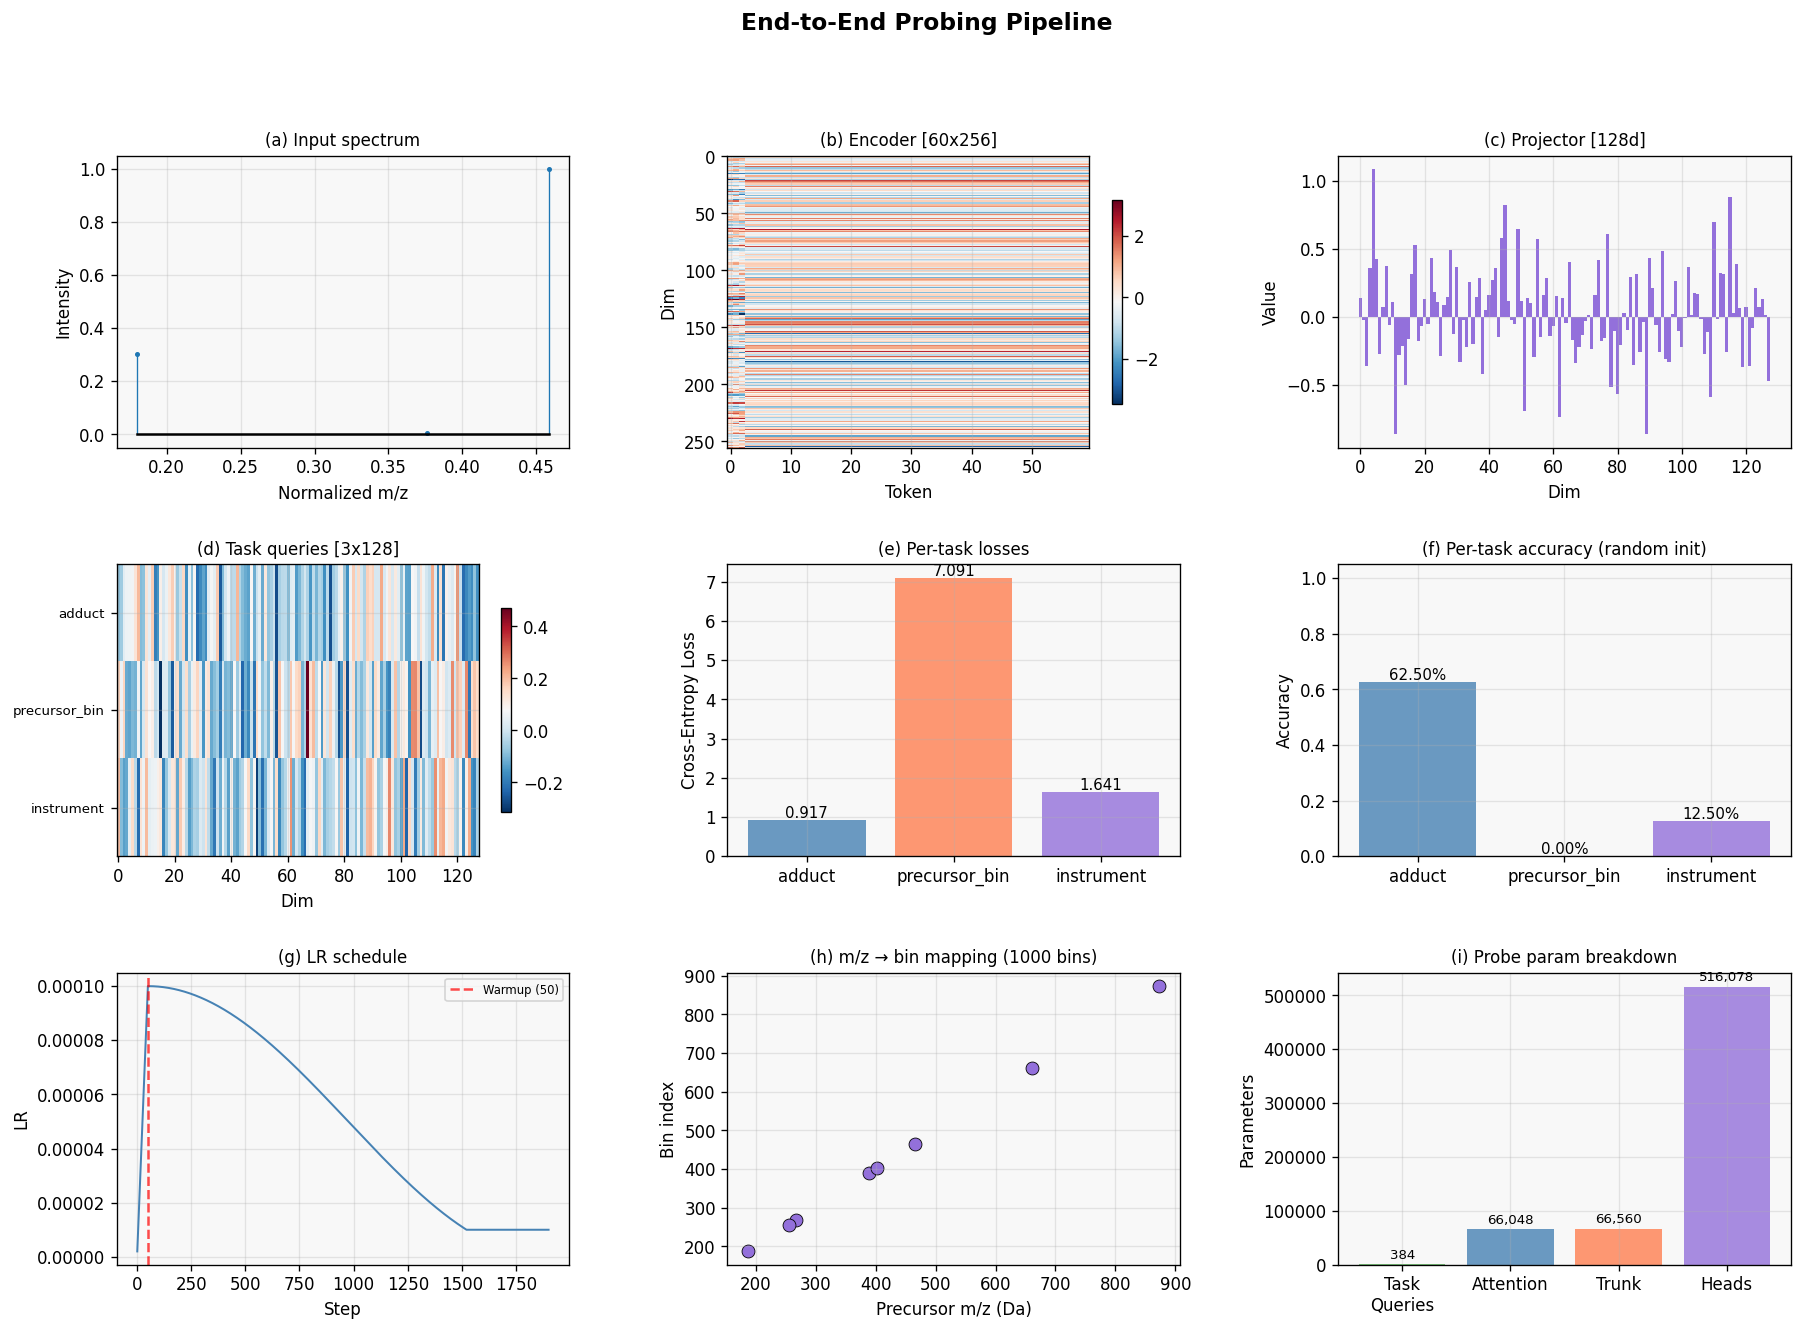


=== Pipeline Summary ===
Data: MassSpecGym (train=194,119, test=17,556)
Backbone: 12,525,056 params (frozen=True)
Feature source: projector → dim=128
Probe: 649,070 params (attentive, 3 tasks)
Tasks: ['adduct', 'precursor_bin', 'instrument']
Schedule: cosine decay, warmup=50, total_steps=1900
Optimizer: AdamW (lr=0.0001, wd=0.0001)


In [13]:
# Summary figure
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('End-to-End Probing Pipeline', fontsize=14, fontweight='bold', y=0.98)

# (a) Input spectrum
ax = fig.add_subplot(gs[0, 0])
s = 0
mz = small_batch['peak_mz'][s].numpy()
intensity = small_batch['peak_intensity'][s].numpy()
valid = small_batch['peak_valid_mask'][s].numpy().astype(bool)
v_idx = np.where(valid)[0]
if len(v_idx) > 0:
    markerline, stemlines, baseline = ax.stem(
        mz[v_idx], intensity[v_idx], linefmt='C0-', markerfmt='C0o', basefmt='k-',
    )
    stemlines.set_linewidth(0.8)
    markerline.set_markersize(2)
ax.set_title('(a) Input spectrum', fontsize=10)
ax.set_xlabel('Normalized m/z')
ax.set_ylabel('Intensity')

# (b) Encoder output heatmap
ax = fig.add_subplot(gs[0, 1])
im = ax.imshow(enc_features[s].numpy().T, aspect='auto', cmap='RdBu_r', interpolation='nearest')
ax.set_title(f'(b) Encoder [{cfg.num_peaks}x{cfg.model_dim}]', fontsize=10)
ax.set_xlabel('Token')
ax.set_ylabel('Dim')
plt.colorbar(im, ax=ax, shrink=0.7)

# (c) Projected feature
ax = fig.add_subplot(gs[0, 2])
ax.bar(range(proj_features.shape[2]), proj_features[s, 0].numpy(), color='mediumpurple', width=1.0)
ax.set_title(f'(c) Projector [{cfg.sigreg_proj_output_dim}d]', fontsize=10)
ax.set_xlabel('Dim')
ax.set_ylabel('Value')

# (d) Task query embeddings (before attention)
ax = fig.add_subplot(gs[1, 0])
tq = probe.task_queries.detach().numpy()  # [3, input_dim]
im = ax.imshow(tq, aspect='auto', cmap='RdBu_r', interpolation='nearest')
ax.set_yticks(range(len(PROBE_TASK_NAMES)))
ax.set_yticklabels(PROBE_TASK_NAMES, fontsize=8)
ax.set_title(f'(d) Task queries [{len(PROBE_TASK_NAMES)}x{input_dim}]', fontsize=10)
ax.set_xlabel('Dim')
plt.colorbar(im, ax=ax, shrink=0.7)

# (e) Per-task losses
ax = fig.add_subplot(gs[1, 1])
task_losses = [result['losses'][n].item() for n in PROBE_TASK_NAMES]
bars = ax.bar(PROBE_TASK_NAMES, task_losses, color=['steelblue', 'coral', 'mediumpurple'], alpha=0.8)
for bar, val in zip(bars, task_losses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.3f}', ha='center', fontsize=9)
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('(e) Per-task losses', fontsize=10)

# (f) Per-task accuracies
ax = fig.add_subplot(gs[1, 2])
task_accs = []
for name in PROBE_TASK_NAMES:
    preds = result['logits'][name].detach().argmax(dim=1)
    targets = result['targets'][name]
    acc = (preds == targets).float().mean().item()
    task_accs.append(acc)
bars = ax.bar(PROBE_TASK_NAMES, task_accs, color=['steelblue', 'coral', 'mediumpurple'], alpha=0.8)
for bar, val in zip(bars, task_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2%}', ha='center', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('(f) Per-task accuracy (random init)', fontsize=10)

# (g) LR schedule
ax = fig.add_subplot(gs[2, 0])
ax.plot(steps, lrs, color='steelblue', lw=1.2)
ax.axvline(probe_warmup, color='red', ls='--', alpha=0.7, label=f'Warmup ({probe_warmup})')
ax.set_xlabel('Step')
ax.set_ylabel('LR')
ax.set_title('(g) LR schedule', fontsize=10)
ax.legend(fontsize=7)

# (h) Precursor bin mapping example
ax = fig.add_subplot(gs[2, 1])
prec_mz_raw = small_batch['precursor_mz'][:8].numpy() * float(cfg.max_precursor_mz)
prec_bins = result['targets']['precursor_bin'].numpy()
ax.scatter(prec_mz_raw, prec_bins, c='mediumpurple', s=60, edgecolors='k', linewidths=0.5)
ax.set_xlabel('Precursor m/z (Da)')
ax.set_ylabel('Bin index')
ax.set_title(f'(h) m/z \u2192 bin mapping ({num_precursor_bins} bins)', fontsize=10)

# (i) Parameter breakdown
ax = fig.add_subplot(gs[2, 2])
components = ['Task\nQueries', 'Attention', 'Trunk', 'Heads']
param_counts = [query_params, attn_params, trunk_params, head_params]
colors = ['#5cb85c', 'steelblue', 'coral', 'mediumpurple']
bars = ax.bar(components, param_counts, color=colors, alpha=0.8)
for bar, p in zip(bars, param_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(param_counts)*0.02,
            f'{p:,}', ha='center', fontsize=8)
ax.set_ylabel('Parameters')
ax.set_title('(i) Probe param breakdown', fontsize=10)

plt.savefig('notebooks/fig_probe_summary.png', bbox_inches='tight')
plt.show()

print('\n=== Pipeline Summary ===')
print(f'Data: MassSpecGym (train={dm.info["massspec_train_size"]:,}, test={dm.info["massspec_test_size"]:,})')
print(f'Backbone: {total_params:,} params (frozen={cfg.final_probe_freeze_backbone})')
print(f'Feature source: {cfg.final_probe_feature_source} \u2192 dim={input_dim}')
print(f'Probe: {probe_params:,} params (attentive, {len(PROBE_TASK_NAMES)} tasks)')
print(f'Tasks: {list(PROBE_TASK_NAMES)}')
print(f'Schedule: cosine decay, warmup={probe_warmup}, total_steps={total_probe_steps}')
print(f'Optimizer: AdamW (lr={probe_lr}, wd={cfg.final_probe_weight_decay})')